In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

from scipy.integrate import odeint

In [2]:
def solve(y0, t, eps=0.01):
    ys = [y0]
    dt = t[1] - t[0]
    for i in range(t.shape[0] - 1):
        y = ys[-1]
        y1 = y[0:1] + y[1:2] * dt
        y2 = y[1:2] + (-y[0:1] - y[1:2]) * dt + np.sqrt(eps * dt) * np.random.normal(size=y[0:1].shape)
        ys += [np.concatenate([y1, y2], axis=0)]
    return ys

In [3]:
T = 5
t = np.linspace(0, T, 501).reshape([-1, 1])
y0 = 1 * np.random.normal(size=[2, 100000])

eps = 0.01
ys = solve(y0, t, eps=eps)
ys = np.stack(ys, axis=0)

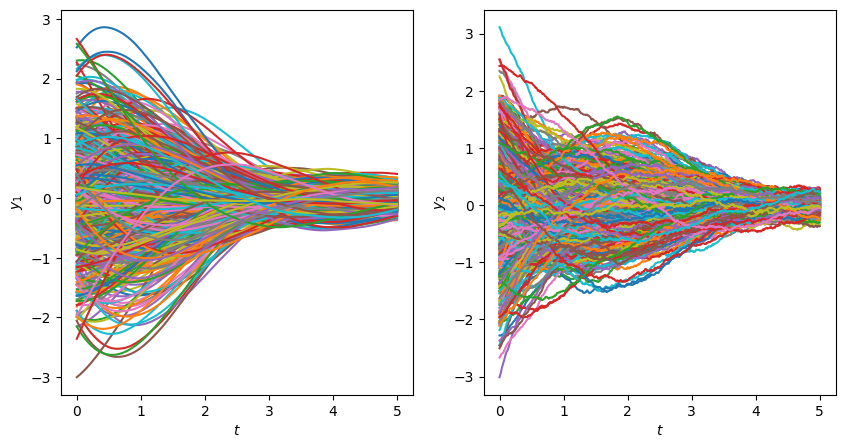

In [4]:
fig = plt.figure(figsize=[10, 5])

ax = fig.add_subplot(1, 2, 1)
ax.plot(t, ys[:, 0, 0:500])
ax.set_xlabel("$t$")
ax.set_ylabel("$y_1$")

ax = fig.add_subplot(1, 2, 2)
ax.plot(t, ys[:, 1, 0:500])
ax.set_xlabel("$t$")
ax.set_ylabel("$y_2$")

plt.show()

In [5]:
sio.savemat(
    "./train.mat",
    {
        "t": t,
        "ys": ys,
        "eps": eps,
        "T": T
    }
)

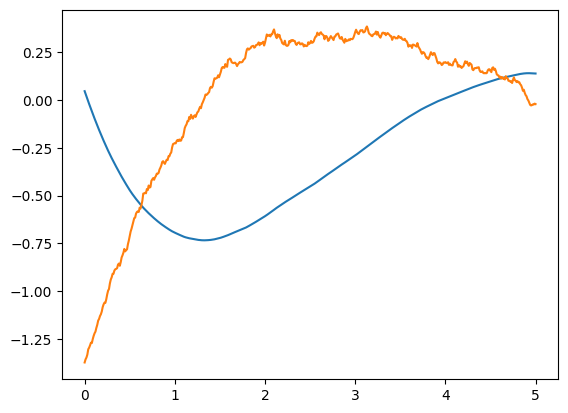

In [6]:
plt.plot(t, ys[:, 0, 100])
plt.plot(t, ys[:, 1, 100])